In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree


# IO

In [5]:
import pandas as pd
import math
# 定义列名
columns = [
    "compressed", "probe_side", "build_side", "sel", "payload", "dist",
    "cluster_hit_ratio", "build_dis", "probe_dis", "mat_strat", "queue_thr", "latency"
]

data = []
with open('origin_data/microbench/io_time_0205.txt', 'r') as file:
    lines = file.readlines()
    for i in range(0, len(lines), 2):

        values = lines[i].strip().split()
        values = [int(values[0]), int(values[1]), int(values[2]), float(values[3]), int(values[4]),
                  values[5], float(values[6]), values[7], values[8], int(values[9]), int(values[10])]
        latency = float(lines[i + 1].strip())
        values.append(latency)
        data.append(values)

df = pd.DataFrame(data, columns=columns)
df = df[(df['compressed'] == 1) & 
        (df['build_dis'] == 'random') & 
        (df['probe_dis'] == 'random') & 
        (df['dist'] == 'uniform') & (df['queue_thr'] != 10)& (df['queue_thr'] != 100)& (df['queue_thr'] != 5000)]

df['processed_payload'] = df.apply(lambda row: 4 if row['mat_strat'] == 1 else row['payload'], axis=1)
sampled_df = df.sample(frac=0.2, random_state=42)  

# df['build_side'] = np.sqrt(df['build_side'])
y = sampled_df['latency']

In [6]:
features = pd.DataFrame(sampled_df['build_side']*(sampled_df['processed_payload']+5)+8* sampled_df['build_side']*2, columns=['memcpy'])

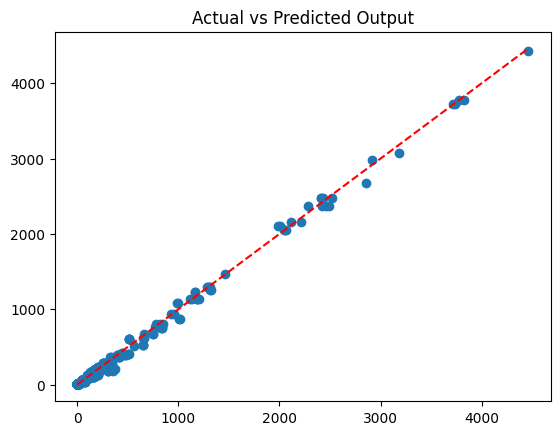

In [7]:
io = LinearRegression()
io = GradientBoostingRegressor()
io.fit(features, y)
# print("Coefficients:", io.coef_)
# print("Intercept:", io.intercept_)

# 预测输出
y_pred = io.predict(features)
min_val = min(min(y), min(y_pred))
max_val = max(max(y), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='x=y')

plt.scatter(y, y_pred)
# for i in range(len(y)):
#     if y.iloc[i]<400 and y.iloc[i]>220 and y_pred[i] -y.iloc[i]>100 :
#         print(float(features.iloc[i][0]) , y.iloc[i], y_pred[i])


plt.title("Actual vs Predicted Output")
plt.show()

# Hash table build time

In [12]:
import pandas as pd
import math

columns = [
    "compressed", "probe_side", "build_side", "sel", "payload", "dist",
    "cluster_hit_ratio", "build_dis", "probe_dis", "mat_strat", "queue_thr", "latency"
]

data = []
with open('origin_data/microbench/payload_hash_table_build_time_0205.txt', 'r') as file:
    lines = file.readlines()
    for i in range(0, len(lines), 2):
        values = lines[i].strip().split()
        values = [int(values[0]), int(values[1]), int(values[2]), float(values[3]), int(values[4]),
                  values[5], float(values[6]), values[7], values[8], int(values[9]), int(values[10])]
        latency = float(lines[i + 1].strip())
        values.append(latency)
        data.append(values)

df = pd.DataFrame(data, columns=columns)
df = df[(df['compressed'] == 1) & 
        (df['build_dis'] == 'random') & 
        (df['probe_dis'] == 'random') & 
        (df['dist'] == 'uniform')]


df['processed_payload'] = df.apply(lambda row: 4 if row['mat_strat'] == 1 else row['payload'], axis=1)
# df['build_side'] = np.sqrt(df['build_side'])
sampled_df = df.sample(frac=0.2, random_state=42)  
features = sampled_df[['build_side']]

y = sampled_df['latency']

In [13]:
features['memcpy'] = sampled_df['build_side']*(sampled_df['processed_payload']+5)+8* sampled_df['build_side']*2

/tmp/ipykernel_2947308/3445231442.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['memcpy'] = sampled_df['build_side']*(sampled_df['processed_payload']+5)+8* sampled_df['build_side']*2


Coefficients: [6.49156370e-06 4.59394743e-07]
Intercept: 1.3835303021224945
18000000.0 2196000000.0 1017.94 1127.0625319012702


/tmp/ipykernel_2947308/1414778913.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(float(features.iloc[i][0]),float(features.iloc[i][1]) , y.iloc[i], y_pred[i])


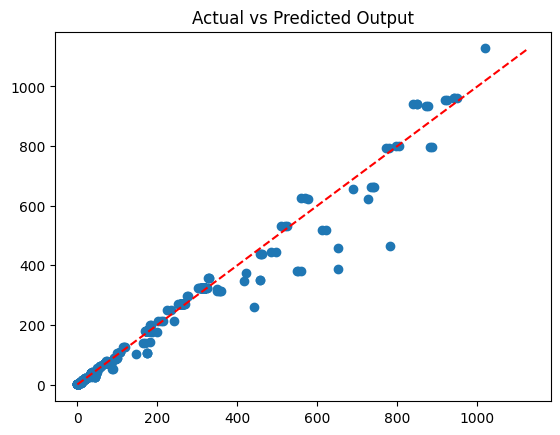

In [15]:
hash_table_build = LinearRegression()
# hash_table_build = GradientBoostingRegressor()
hash_table_build.fit(features, y)
print("Coefficients:", hash_table_build.coef_)
print("Intercept:", hash_table_build.intercept_)

y_pred = hash_table_build.predict(features)
min_val = min(min(y), min(y_pred))
max_val = max(max(y), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='x=y')

plt.scatter(y, y_pred)
# for i in range(len(y)):
#     if y.iloc[i]<400 and y.iloc[i]>220 and y_pred[i] -y.iloc[i]>100 :
#         print(float(features.iloc[i][0]),float(features.iloc[i][1]) , y.iloc[i], y_pred[i])

for i in range(len(y)):
    if y_pred[i]<1200 and y_pred[i]>1020 and abs(y_pred[i] -y.iloc[i])>50 :
        print(float(features.iloc[i][0]),float(features.iloc[i][1]) , y.iloc[i], y_pred[i])

plt.title("Actual vs Predicted Output")
plt.show()

# Map building Time

In [21]:
import pandas as pd
import numpy as np

columns = [
    "compressed", "probe_side", "build_side", "sel", "payload", "dist",
    "cluster_hit_ratio", "build_dis", "probe_dis", "mat_strat", "queue_thr",
    "materialize_times", "single_time_avg_rows", "total_materialized_chunks",
    "total_materialized_rows", "map_building_time", "mat_operator_time"
]

data = []
with open('origin_data/microbench/payload_build_time_0205.txt', 'r') as file:
    lines = file.readlines()
    for i in range(0, len(lines), 2):
        values = lines[i].strip().split()
        values = [int(values[0]), int(values[1]), int(values[2]), float(values[3]), int(values[4]),
                  values[5], float(values[6]), values[7], values[8], int(values[9]), int(values[10])]
        additional_values = lines[i + 1].strip().split()
        additional_values = [int(additional_values[0]), float(additional_values[1]), int(additional_values[2]),
                             int(additional_values[3]), float(additional_values[4]), float(additional_values[5])]
        values.extend(additional_values)
        data.append(values)

df = pd.DataFrame(data, columns=columns)
df = df[(df['compressed'] == 1) & 
        (df['build_dis'] == 'random') & 
        (df['probe_dis'] == 'random') & 
        (df['dist'] == 'uniform')]
sampled_df = df.sample(frac=0.2, random_state=42)  


In [22]:
features = sampled_df[['build_side','single_time_avg_rows']]
# features  = df.iloc[:,[2,3,12]]
y = sampled_df['map_building_time']/sampled_df["materialize_times"]


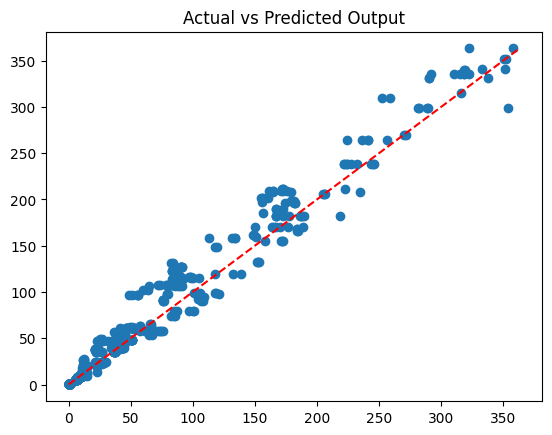

In [23]:
# map_build_model = DecisionTreeRegressor(max_depth=8)
map_build_model = GradientBoostingRegressor()
# map_build_model = LinearRegression()
map_build_model.fit(features, y)
# print("Coefficients:", model.coef_)
# print("Intercept:", model.intercept_)

# 预测输出
y = y*sampled_df["materialize_times"]
y_pred = map_build_model.predict(features)*sampled_df["materialize_times"]
min_val = min(min(y), min(y_pred))
max_val = max(max(y), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='x=y')

plt.scatter(y, y_pred)
# for i in range(len(y)):
#     if y_pred[i]<140 and y_pred[i]>80 and y.iloc[i]>130 :
#         print(float(features.iloc[i][0]),float(features.iloc[i][1]),float(features.iloc[i][2]),float(features.iloc[i][3]),float(features.iloc[i][4]) , y.iloc[i], y_pred[i])


plt.title("Actual vs Predicted Output")
plt.show()

# Batch Materialize Time

In [25]:
import pandas as pd
import numpy as np

columns = [
    "compressed", "probe_side", "build_side", "sel", "payload", "dist",
    "cluster_hit_ratio", "build_dis", "probe_dis", "mat_strat", "queue_thr",
    "materialize_times", "single_time_avg_rows", "total_materialized_chunks",
    "total_materialized_rows", "map_building_time", "mat_operator_time"
]

data = []
with open('origin_data/microbench/payload_build_time_0205.txt', 'r') as file:
    lines = file.readlines()
    for i in range(0, len(lines), 2):
        values = lines[i].strip().split()
        values = [int(values[0]), int(values[1]), int(values[2]), float(values[3]), int(values[4]),
                  values[5], float(values[6]), values[7], values[8], int(values[9]), int(values[10])]
        additional_values = lines[i + 1].strip().split()
        additional_values = [int(additional_values[0]), float(additional_values[1]), int(additional_values[2]),
                             int(additional_values[3]), float(additional_values[4]), float(additional_values[5])]
        values.extend(additional_values)
        data.append(values)

df = pd.DataFrame(data, columns=columns)
df = df[(df['compressed'] == 1) & 
        (df['build_dis'] == 'random') & 
        (df['probe_dis'] == 'random') & 
        (df['dist'] == 'uniform')]
sampled_df = df.sample(frac=0.2, random_state=42) 


In [26]:
features = sampled_df[['build_side','single_time_avg_rows','total_materialized_rows','payload']]

y = sampled_df['mat_operator_time']

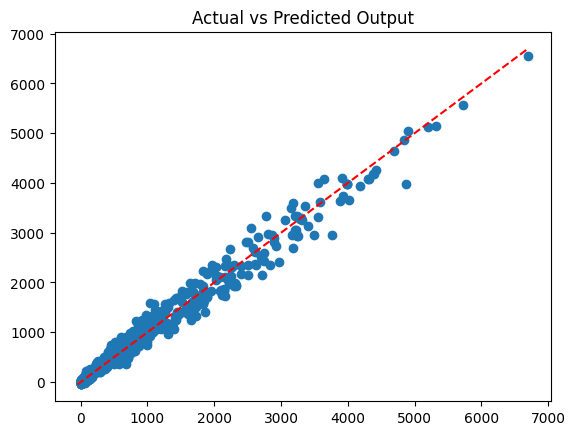

In [27]:
mat_model = GradientBoostingRegressor()
# mat_model = DecisionTreeRegressor(max_depth=10)
mat_model.fit(features, y)
# print("Coefficients:", model.coef_)
# print("Intercept:", model.intercept_)


y = y
y_pred = mat_model.predict(features)
min_val = min(min(y), min(y_pred))
max_val = max(max(y), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='x=y')

plt.scatter(y, y_pred)
# for i in range(len(y)):
#     if y_pred[i]<140 and y_pred[i]>80 and y.iloc[i]>130 :
#         print(float(features.iloc[i][0]),float(features.iloc[i][1]),float(features.iloc[i][2]),float(features.iloc[i][3]),float(features.iloc[i][4]) , y.iloc[i], y_pred[i])


plt.title("Actual vs Predicted Output")
plt.show()

# Test Regressor

In [28]:
def io_time(predict_df):
    # return io.predict(predict_df) 
    return float((1.78804854e-06*predict_df['memcpy'] -81.60589871649347).iloc[0])
def map_build_time(predict_df, time):
    return map_build_model.predict(predict_df) * time
def batch_materialize_time(predict_df):
    return mat_model.predict(predict_df)
def ht_build(predict_df):
    return float((5.23663053e-06*predict_df['build_side']+ 4.98432828e-07*predict_df['memcpy'] + 1.5774507566396068).iloc[0])
    return hash_table_build.predict(predict_df)


In [36]:
# build_size, payload, sel, chunk_thr
# single_row_avg = probe_size*sel/times, times = probe_size/2048/chunk_thr
probe_size = 20000000
def pred_em(feature):
    features = {
        'build_side': [feature[0]],
        'memcpy': [feature[0]*(feature[1]+5)+8* feature[0]*2]
    }
    predict_df = pd.DataFrame(features)
    ht_build_ = ht_build(predict_df)
    features = {
        'memcpy': [feature[0]*(feature[1]+5)+8* feature[0]*2]
    }
    predict_df = pd.DataFrame(features)
    io_time_ = io_time(predict_df)
    return ht_build_+io_time_
def pred_lm(feature):
    features = {
        'memcpy': [feature[0]*(feature[1]+5)+8* feature[0]*2]
    }
    predict_df = pd.DataFrame(features)
    io_time_ = io_time(predict_df)
    times = probe_size/2048/feature[3]
    single_row_avg = probe_size*feature[2]/times
    features = {
        'build_side': [feature[0]],
        'single_time_avg_rows': [single_row_avg]
    }
    predict_df = pd.DataFrame(features)
    map_build_ = map_build_time(predict_df,times)
    features['total_materialized_rows'] =  [feature[2]*probe_size]
    features['payload'] = [feature[1]]
    
    predict_df = pd.DataFrame(features)
    
    batch_mat_ = batch_materialize_time(predict_df)
    features_ht = {
        'build_side': [feature[0]],
        'memcpy': [feature[0]*(feature[1]+5)+8* feature[0]*2]
    }

    predict_df = pd.DataFrame(features_ht)
    ht_build_ = ht_build(predict_df)
    return ht_build_ + map_build_ + batch_mat_+io_time_
                                                                                                                                          


In [37]:
import pandas as pd


columns = [
    "thread_num","compressed", "probe_side", "build_side", "sel", "payload", "dist",
    "cluster_hit_ratio", "build_dis", "probe_dis", "mat_strat", "queue_thr", "latency"
]
#/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark_time_0110_dropcache.txt
df = pd.read_csv('origin_data/microbench/benchmark_time_0205_dropcache.txt',sep=' ',header=None, names=columns)

df = df[(df['compressed'] == 1) & 
        (df['build_dis'] == 'random') & 
        (df['probe_dis'] == 'random') & 
        (df['dist'] == 'uniform') & (df['queue_thr']!=10) ]
df['payload_processed'] = df.apply(lambda row: 4 if row['mat_strat'] == 1 else row['payload'], axis=1)
grouped = df.groupby(['build_side', 'sel', 'payload'])


# Table 2

In [38]:
counter = 0
total = 0
group_counter = 0
group_total = 0
avg_latency_em= 0
avg_latency_lm =0
avg_latency_best = 0
avg_latency_pick = 0
for names, group in grouped:
    # print(names)
    # print(group)
    em_time = group[group['mat_strat']==0]['latency']
    minimal_late = 1000000000
    pred_early = 0
    pred_late = minimal_late
    for queue_thr in group[group['mat_strat']==1]['queue_thr'].unique():
        lm_time = group[(group['mat_strat']==1) & (group['queue_thr']==queue_thr)]['latency']
        if float(lm_time.iloc[0]) < minimal_late:
            minimal_late = float(lm_time.iloc[0]) 
        features = [names[0], names[2], names[1],queue_thr]
        
        early = pred_em(features)
        pred_early = early
        features = [names[0], 4, names[1],queue_thr]
        late = pred_lm(features)
        if late<pred_late:
            pred_late = late
        counter += (early> late)==(float(em_time.iloc[0])>float(lm_time.iloc[0]))
        total+=1
    group_total+=1
    group_counter+=  (pred_early> pred_late)==(float(em_time.iloc[0])>float(minimal_late))
    pick_late = pred_early > pred_late
    pick = float(em_time.iloc[0])
    if pick_late:
        pick = minimal_late
    avg_latency_em += float(em_time.iloc[0])
    avg_latency_lm += float(minimal_late)
    avg_latency_best += min(em_time.iloc[0], minimal_late)
    avg_latency_pick += pick
    
print('Single accuracy: ',counter/total)
print('Group accuracy: ',group_counter/group_total)
print('pure em:', avg_latency_em/group_total, 'pure lm:',avg_latency_lm/group_total, 'best:',avg_latency_best/group_total, 'selective:',avg_latency_pick/group_total)


Single accuracy:  [0.83480306]
Group accuracy:  [0.81746032]
pure em: 1757.0989797178129 pure lm: 1999.3296596119903 best: 1632.953688712521 selective: 1650.3761737213397
